In [1]:
import pandas as pd
def carga_parquet(ruta):

# Leer el archivo Parquet
    df = pd.read_parquet(ruta)
    return(df)


In [3]:
df_caracteristicas=carga_parquet('../output/caracteristicas.parquet')
df_caracteristicas

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Motor,Schneider,X100,1009,9656
1,2,Motor,ABB,Z300,1220,2165
2,3,Motor,GE,Y200,3733,6674
3,4,Transformador,Siemens,X100,662,1480
4,5,Compresor,ABB,Y200,982,4282
...,...,...,...,...,...,...
495,496,Motor,Siemens,X100,3617,5594
496,497,Generador,Schneider,Y200,548,8614
497,498,Motor,Schneider,M400,2602,5874
498,499,Motor,ABB,M400,877,6907


In [4]:
df_ordenes=carga_parquet('../output/ordenes.parquet')
df_ordenes

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,465,2020-01-01 00:00:00,Correctivo,1405.20,47,Planta Norte
1,2,418,2020-01-01 01:00:00,Correctivo,5922.92,38,Planta Norte
2,3,228,2020-01-01 02:00:00,Correctivo,7119.05,34,Planta Oeste
3,4,300,2020-01-01 03:00:00,Correctivo,3488.33,38,Planta Oeste
4,5,325,2020-01-01 04:00:00,Correctivo,5611.37,15,Planta Este
...,...,...,...,...,...,...,...
9995,9996,42,2021-02-20 11:00:00,Preventivo,2790.17,25,Planta Este
9996,9997,66,2021-02-20 12:00:00,Correctivo,3802.44,3,Planta Sur
9997,9998,289,2021-02-20 13:00:00,Correctivo,4525.96,23,Planta Este
9998,9999,209,2021-02-20 14:00:00,Preventivo,1871.95,30,Planta Oeste


In [5]:
df_registros=carga_parquet('../output/registros.parquet')
df_registros

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,147,2020-01-01 00:00:00,124.61,3.49,61609.0
1,2,111,2020-01-01 01:00:00,58.12,3.62,49474.0
2,3,475,2020-01-01 02:00:00,124.86,3.36,59760.0
3,4,337,2020-01-01 03:00:00,110.45,1.56,27752.0
4,5,212,2020-01-01 04:00:00,70.53,4.89,33066.0
...,...,...,...,...,...,...
8995,8996,201,2021-01-09 19:00:00,112.75,1.07,56253.0
8996,8997,475,2021-01-09 20:00:00,50.67,3.28,27276.0
8997,8998,96,2021-01-09 21:00:00,133.86,0.74,75860.0
8998,8999,449,2021-01-09 22:00:00,84.72,1.77,11775.0


In [6]:
df_tabla_final=carga_parquet('../output/tabla_final.parquet')
df_tabla_final.columns

Index(['ID_Equipo', 'Total_Ordenes', 'Ordenes_Correctivo',
       'Ordenes_Preventivo', 'MEDIA_DIAS_ENTRE_MTOS',
       'MEDIA_DIAS_ENTRE_MTO_PREV', 'DIAS_ENTRE_FALL_CONSEC',
       'Vida_util_estimada', 'MEDIA_TEMP', 'MEDIA_VIBR',
       'MEDIA_HORAS_OPERATIVAS', 'COSTE_MTO_CORR_MEDIO_POR_ORDEN',
       'DURACION_HORAS_CORR_MEDIO_POR_ORDEN', 'COSTE_MTO_CORR_TOTAL',
       'DURACION_HORAS_CORR_TOTAL', 'COSTE_MTO_PREV_MEDIO_POR_ORDEN',
       'DURACION_HORAS_PREV_MEDIO_POR_ORDEN', 'COSTE_MTO_PREV_TOTAL',
       'DURACION_HORAS_PREV_TOTAL', 'COSTE_MTO_MEDIO_POR_ORDEN',
       'DURACION_HORAS_MEDIO_POR_ORDEN', 'COSTE_MTO_TOTAL',
       'DURACION_HORAS_TOTAL', 'Tipo_Equipo', 'Fabricante', 'Modelo',
       'Potencia_kW', 'Horas_Recomendadas_Revision'],
      dtype='object')

In [7]:
df_otras_caract=df_tabla_final[['ID_Equipo','DIAS_ENTRE_FALL_CONSEC','MEDIA_TEMP', 'MEDIA_VIBR',
       'MEDIA_HORAS_OPERATIVAS', 'Ordenes_Correctivo', 'DURACION_HORAS_CORR_MEDIO_POR_ORDEN', 'DURACION_HORAS_CORR_TOTAL','COSTE_MTO_CORR_TOTAL', 'COSTE_MTO_CORR_MEDIO_POR_ORDEN']]
df_otras_caract

,ID_Equipo,DIAS_ENTRE_FALL_CONSEC,MEDIA_TEMP,MEDIA_VIBR,MEDIA_HORAS_OPERATIVAS,Ordenes_Correctivo,DURACION_HORAS_CORR_MEDIO_POR_ORDEN,DURACION_HORAS_CORR_TOTAL,COSTE_MTO_CORR_TOTAL,COSTE_MTO_CORR_MEDIO_POR_ORDEN
0,1,39.111111,106.908125,2.346250,48090.312500,10,15.400000,154,52848.73,5284.873000
1,2,55.333333,95.310000,2.400769,64532.615385,7,16.857143,118,22879.74,3268.534286
2,3,41.666667,93.922778,3.232222,42117.111111,10,12.800000,128,29236.02,2923.602000
3,4,34.454545,90.881500,2.278500,56715.350000,12,23.500000,282,82749.39,6895.782500
4,5,38.000000,107.714643,2.693214,54120.142857,10,24.400000,244,47873.65,4787.365000
...,...,...,...,...,...,...,...,...,...,...
494,495,29.909091,105.388947,2.308947,54310.421053,12,21.583333,259,70900.69,5908.390833
495,496,40.000000,91.598750,2.845000,46477.541667,10,29.300000,293,58508.27,5850.827000
496,497,35.700000,114.621053,2.642105,53482.947368,11,21.272727,234,54972.12,4997.465455
497,498,33.888889,100.603333,2.572667,56706.866667,10,24.600000,246,53954.26,5395.426000


UNIMOS LAS TABLAS DE CARACTERISTICAS, OTRAS CARACTERISTICAS Y ORDENES

In [8]:
tabla_aux = pd.merge(df_caracteristicas,df_otras_caract, on="ID_Equipo")
tabla_aux

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,DIAS_ENTRE_FALL_CONSEC,MEDIA_TEMP,MEDIA_VIBR,MEDIA_HORAS_OPERATIVAS,Ordenes_Correctivo,DURACION_HORAS_CORR_MEDIO_POR_ORDEN,DURACION_HORAS_CORR_TOTAL,COSTE_MTO_CORR_TOTAL,COSTE_MTO_CORR_MEDIO_POR_ORDEN
0,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.346250,48090.312500,10,15.400000,154,52848.73,5284.873000
1,2,Motor,ABB,Z300,1220,2165,55.333333,95.310000,2.400769,64532.615385,7,16.857143,118,22879.74,3268.534286
2,3,Motor,GE,Y200,3733,6674,41.666667,93.922778,3.232222,42117.111111,10,12.800000,128,29236.02,2923.602000
3,4,Transformador,Siemens,X100,662,1480,34.454545,90.881500,2.278500,56715.350000,12,23.500000,282,82749.39,6895.782500
4,5,Compresor,ABB,Y200,982,4282,38.000000,107.714643,2.693214,54120.142857,10,24.400000,244,47873.65,4787.365000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,495,Compresor,Schneider,Y200,4383,6188,29.909091,105.388947,2.308947,54310.421053,12,21.583333,259,70900.69,5908.390833
495,496,Motor,Siemens,X100,3617,5594,40.000000,91.598750,2.845000,46477.541667,10,29.300000,293,58508.27,5850.827000
496,497,Generador,Schneider,Y200,548,8614,35.700000,114.621053,2.642105,53482.947368,11,21.272727,234,54972.12,4997.465455
497,498,Motor,Schneider,M400,2602,5874,33.888889,100.603333,2.572667,56706.866667,10,24.600000,246,53954.26,5395.426000


In [9]:
tabla_modelo= pd.merge(tabla_aux,df_ordenes, on="ID_Equipo")
tabla_modelo

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,DIAS_ENTRE_FALL_CONSEC,MEDIA_TEMP,MEDIA_VIBR,MEDIA_HORAS_OPERATIVAS,...,DURACION_HORAS_CORR_MEDIO_POR_ORDEN,DURACION_HORAS_CORR_TOTAL,COSTE_MTO_CORR_TOTAL,COSTE_MTO_CORR_MEDIO_POR_ORDEN,ID_Orden,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,...,15.40,154,52848.73,5284.873,929,2020-02-08 16:00:00,Correctivo,3143.58,8,Planta Este
1,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,...,15.40,154,52848.73,5284.873,1071,2020-02-14 14:00:00,Correctivo,2662.10,38,Planta Este
2,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,...,15.40,154,52848.73,5284.873,1519,2020-03-04 06:00:00,Correctivo,6329.16,3,Planta Sur
3,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,...,15.40,154,52848.73,5284.873,2093,2020-03-28 04:00:00,Preventivo,2645.45,28,Planta Este
4,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,...,15.40,154,52848.73,5284.873,2487,2020-04-13 14:00:00,Correctivo,6140.86,7,Planta Sur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9945,499,Motor,ABB,M400,877,6907,88.333333,95.410000,2.76100,61050.0000,...,33.25,133,20625.56,5156.390,7594,2020-11-12 09:00:00,Preventivo,5636.49,32,Planta Oeste
9946,499,Motor,ABB,M400,877,6907,88.333333,95.410000,2.76100,61050.0000,...,33.25,133,20625.56,5156.390,7769,2020-11-19 16:00:00,Preventivo,6220.96,42,Planta Norte
9947,499,Motor,ABB,M400,877,6907,88.333333,95.410000,2.76100,61050.0000,...,33.25,133,20625.56,5156.390,8004,2020-11-29 11:00:00,Preventivo,7804.82,9,Planta Sur
9948,499,Motor,ABB,M400,877,6907,88.333333,95.410000,2.76100,61050.0000,...,33.25,133,20625.56,5156.390,8845,2021-01-03 12:00:00,Correctivo,4160.08,38,Planta Este


In [10]:
tabla_modelo.drop(columns="Fecha",inplace=True)


In [11]:
tabla_modelo

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,DIAS_ENTRE_FALL_CONSEC,MEDIA_TEMP,MEDIA_VIBR,MEDIA_HORAS_OPERATIVAS,Ordenes_Correctivo,DURACION_HORAS_CORR_MEDIO_POR_ORDEN,DURACION_HORAS_CORR_TOTAL,COSTE_MTO_CORR_TOTAL,COSTE_MTO_CORR_MEDIO_POR_ORDEN,ID_Orden,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.40,154,52848.73,5284.873,929,Correctivo,3143.58,8,Planta Este
1,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.40,154,52848.73,5284.873,1071,Correctivo,2662.10,38,Planta Este
2,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.40,154,52848.73,5284.873,1519,Correctivo,6329.16,3,Planta Sur
3,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.40,154,52848.73,5284.873,2093,Preventivo,2645.45,28,Planta Este
4,1,Motor,Schneider,X100,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.40,154,52848.73,5284.873,2487,Correctivo,6140.86,7,Planta Sur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9945,499,Motor,ABB,M400,877,6907,88.333333,95.410000,2.76100,61050.0000,4,33.25,133,20625.56,5156.390,7594,Preventivo,5636.49,32,Planta Oeste
9946,499,Motor,ABB,M400,877,6907,88.333333,95.410000,2.76100,61050.0000,4,33.25,133,20625.56,5156.390,7769,Preventivo,6220.96,42,Planta Norte
9947,499,Motor,ABB,M400,877,6907,88.333333,95.410000,2.76100,61050.0000,4,33.25,133,20625.56,5156.390,8004,Preventivo,7804.82,9,Planta Sur
9948,499,Motor,ABB,M400,877,6907,88.333333,95.410000,2.76100,61050.0000,4,33.25,133,20625.56,5156.390,8845,Correctivo,4160.08,38,Planta Este


In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(tabla_modelo, title="caso3 Profiling Report",
                        correlations={
                            "pearson": {"calculate": True},
                            "cramers": {"calculate": True},
                        })
profile.to_notebook_iframe()
profile.to_file('caso3_profile_report.html')

In [12]:
tabla_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9950 entries, 0 to 9949
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   ID_Equipo                            9950 non-null   int64   
 1   Tipo_Equipo                          9950 non-null   category
 2   Fabricante                           9950 non-null   category
 3   Modelo                               9950 non-null   category
 4   Potencia_kW                          9950 non-null   int64   
 5   Horas_Recomendadas_Revision          9950 non-null   int64   
 6   DIAS_ENTRE_FALL_CONSEC               9937 non-null   float64 
 7   MEDIA_TEMP                           9950 non-null   float64 
 8   MEDIA_VIBR                           9950 non-null   float64 
 9   MEDIA_HORAS_OPERATIVAS               9950 non-null   float64 
 10  Ordenes_Correctivo                   9950 non-null   int64   
 11  DURACION_HORAS_CO

In [13]:
tabla_modelo.isna().sum()

ID_Equipo                               0
Tipo_Equipo                             0
Fabricante                              0
Modelo                                  0
Potencia_kW                             0
Horas_Recomendadas_Revision             0
DIAS_ENTRE_FALL_CONSEC                 13
MEDIA_TEMP                              0
MEDIA_VIBR                              0
MEDIA_HORAS_OPERATIVAS                  0
Ordenes_Correctivo                      0
DURACION_HORAS_CORR_MEDIO_POR_ORDEN     0
DURACION_HORAS_CORR_TOTAL               0
COSTE_MTO_CORR_TOTAL                    0
COSTE_MTO_CORR_MEDIO_POR_ORDEN          0
ID_Orden                                0
Tipo_Mantenimiento                      0
Costo_Mantenimiento                     0
Duracion_Horas                          0
Ubicacion                               0
dtype: int64

In [14]:
tabla_modelo["DIAS_ENTRE_FALL_CONSEC"].median()

34.63636363636363

In [15]:
import numpy as np
modelo_encoded= tabla_modelo.replace({np.NaN: 34.63},inplace=True)

In [16]:
tabla_modelo.isna().sum()

ID_Equipo                              0
Tipo_Equipo                            0
Fabricante                             0
Modelo                                 0
Potencia_kW                            0
Horas_Recomendadas_Revision            0
DIAS_ENTRE_FALL_CONSEC                 0
MEDIA_TEMP                             0
MEDIA_VIBR                             0
MEDIA_HORAS_OPERATIVAS                 0
Ordenes_Correctivo                     0
DURACION_HORAS_CORR_MEDIO_POR_ORDEN    0
DURACION_HORAS_CORR_TOTAL              0
COSTE_MTO_CORR_TOTAL                   0
COSTE_MTO_CORR_MEDIO_POR_ORDEN         0
ID_Orden                               0
Tipo_Mantenimiento                     0
Costo_Mantenimiento                    0
Duracion_Horas                         0
Ubicacion                              0
dtype: int64

In [17]:
from sklearn.compose import make_column_selector as selector
categorical_columns_selector = selector(dtype_include="category")
categorical_columns = categorical_columns_selector(tabla_modelo)
a=tabla_modelo[categorical_columns]
a

,Tipo_Equipo,Fabricante,Modelo,Tipo_Mantenimiento,Ubicacion
0,Motor,Schneider,X100,Correctivo,Planta Este
1,Motor,Schneider,X100,Correctivo,Planta Este
2,Motor,Schneider,X100,Correctivo,Planta Sur
3,Motor,Schneider,X100,Preventivo,Planta Este
4,Motor,Schneider,X100,Correctivo,Planta Sur
...,...,...,...,...,...
9945,Motor,ABB,M400,Preventivo,Planta Oeste
9946,Motor,ABB,M400,Preventivo,Planta Norte
9947,Motor,ABB,M400,Preventivo,Planta Sur
9948,Motor,ABB,M400,Correctivo,Planta Este


In [18]:
for col in a:
    print(a[col].unique())

['Motor', 'Transformador', 'Compresor', 'Generador']
Categories (4, object): ['Compresor', 'Generador', 'Motor', 'Transformador']
['Schneider', 'ABB', 'GE', 'Siemens']
Categories (4, object): ['ABB', 'GE', 'Schneider', 'Siemens']
['X100', 'Z300', 'Y200', 'M400']
Categories (4, object): ['M400', 'X100', 'Y200', 'Z300']
['Correctivo', 'Preventivo']
Categories (2, object): ['Correctivo', 'Preventivo']
['Planta Este', 'Planta Sur', 'Planta Oeste', 'Planta Norte']
Categories (4, object): ['Planta Este', 'Planta Norte', 'Planta Oeste', 'Planta Sur']


In [19]:
from sklearn.preprocessing import LabelEncoder
 
modelo_encoded = tabla_modelo.copy()
modelo_encoded[categorical_columns] = tabla_modelo[categorical_columns].apply(LabelEncoder().fit_transform)  
modelo_encoded.head()

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,DIAS_ENTRE_FALL_CONSEC,MEDIA_TEMP,MEDIA_VIBR,MEDIA_HORAS_OPERATIVAS,Ordenes_Correctivo,DURACION_HORAS_CORR_MEDIO_POR_ORDEN,DURACION_HORAS_CORR_TOTAL,COSTE_MTO_CORR_TOTAL,COSTE_MTO_CORR_MEDIO_POR_ORDEN,ID_Orden,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,2,2,1,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.4,154,52848.73,5284.873,929,0,3143.58,8,0
1,1,2,2,1,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.4,154,52848.73,5284.873,1071,0,2662.10,38,0
2,1,2,2,1,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.4,154,52848.73,5284.873,1519,0,6329.16,3,3
3,1,2,2,1,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.4,154,52848.73,5284.873,2093,1,2645.45,28,0
4,1,2,2,1,1009,9656,39.111111,106.908125,2.34625,48090.3125,10,15.4,154,52848.73,5284.873,2487,0,6140.86,7,3


In [20]:
modelo_encoded.describe()

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,DIAS_ENTRE_FALL_CONSEC,MEDIA_TEMP,MEDIA_VIBR,MEDIA_HORAS_OPERATIVAS,Ordenes_Correctivo,DURACION_HORAS_CORR_MEDIO_POR_ORDEN,DURACION_HORAS_CORR_TOTAL,COSTE_MTO_CORR_TOTAL,COSTE_MTO_CORR_MEDIO_POR_ORDEN,ID_Orden,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
count,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000
mean,250.510955,1.488241,1.486633,1.601005,2410.136583,5227.643518,38.055972,99.602028,2.539134,50570.713163,10.670553,24.121757,257.926030,53031.299103,4966.204247,4998.554874,0.491558,4977.342366,24.054372,1.477487
std,144.298855,1.109727,1.133102,1.120806,1433.628194,2732.492795,13.735929,6.974038,0.347091,7124.961136,3.316823,4.228633,92.991731,19013.668047,929.377494,2887.076368,0.499954,2837.233565,13.516646,1.124766
min,1.000000,0.000000,0.000000,0.000000,-100.000000,525.000000,13.000000,79.431429,1.201818,29094.318182,1.000000,12.125000,37.000000,6095.010000,2071.486250,1.000000,0.000000,100.720000,1.000000,0.000000
25%,125.000000,1.000000,0.000000,1.000000,1231.000000,2906.000000,28.416667,94.864286,2.315000,46299.809524,8.000000,21.340909,194.000000,40315.670000,4416.620714,2500.250000,0.000000,2499.255000,12.000000,0.000000
50%,252.000000,1.000000,1.000000,2.000000,2386.000000,5280.000000,34.636364,99.799474,2.541333,50393.500000,11.000000,24.181818,254.000000,52628.680000,5029.499167,4998.500000,0.000000,4916.675000,24.000000,1.000000
75%,376.000000,2.000000,3.000000,3.000000,3558.000000,7468.000000,44.428571,104.635263,2.749500,55311.538352,13.000000,26.769231,312.000000,64872.940000,5577.173077,7498.750000,1.000000,7432.742500,36.000000,2.000000
max,499.000000,3.000000,3.000000,3.000000,4997.000000,9993.000000,108.333333,121.925625,3.509444,68542.384615,21.000000,38.000000,554.000000,114016.500000,8159.061429,10000.000000,1.000000,9999.610000,47.000000,3.000000


In [21]:
# Evaluamos la aportación de cada columna
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

target_column="Tipo_Mantenimiento"

X= modelo_encoded.drop(target_column, axis=1)
y = modelo_encoded[target_column]
 
fvalue_selector = SelectKBest(f_classif, k=2)
 
X_kbest = fvalue_selector.fit(X,y)
 
feature_scores = pd.DataFrame({"Feature": X.columns,"Score": X_kbest.scores_}).sort_values(by="Score", ascending=False)
 

round(feature_scores,2)

,Feature,Score
10,Ordenes_Correctivo,253.90
12,DURACION_HORAS_CORR_TOTAL,205.07
13,COSTE_MTO_CORR_TOTAL,201.38
6,DIAS_ENTRE_FALL_CONSEC,175.25
7,MEDIA_TEMP,3.17
1,Tipo_Equipo,2.95
9,MEDIA_HORAS_OPERATIVAS,1.63
4,Potencia_kW,1.41
11,DURACION_HORAS_CORR_MEDIO_POR_ORDEN,1.11
2,Fabricante,0.88


## 3. Preprocesar Datos
### Eliminar constantes

In [22]:
target_column="Tipo_Mantenimiento"

X= tabla_modelo.drop(target_column, axis=1)
y = tabla_modelo[target_column]

In [28]:


from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=1) # seleccionar características con varianza mayor a 0 o el valor que se desee
sel.fit(X)

no_constant_columns = sel.get_feature_names_out()
len(no_constant_columns)
constant_columns = X.columns.drop(no_constant_columns)


print(("Columnas constantes:"), constant_columns)

tabla_modelo_cleaned = tabla_modelo.drop(constant_columns, axis=1)
print(("Columnas finales:"), tabla_modelo_cleaned.columns, "\n Numero de columnas finales:",len(tabla_modelo_cleaned.columns))

ValueError: could not convert string to float: 'Motor'

In [29]:
# Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split

target_column="Tipo_Mantenimiento"

X= tabla_modelo.drop(target_column, axis=1)
y = tabla_modelo[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(7960, 19) (1990, 19) (7960,) (1990,)


In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9950 entries, 0 to 9949
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   ID_Equipo                            9950 non-null   int64   
 1   Tipo_Equipo                          9950 non-null   category
 2   Fabricante                           9950 non-null   category
 3   Modelo                               9950 non-null   category
 4   Potencia_kW                          9950 non-null   int64   
 5   Horas_Recomendadas_Revision          9950 non-null   int64   
 6   DIAS_ENTRE_FALL_CONSEC               9950 non-null   float64 
 7   MEDIA_TEMP                           9950 non-null   float64 
 8   MEDIA_VIBR                           9950 non-null   float64 
 9   MEDIA_HORAS_OPERATIVAS               9950 non-null   float64 
 10  Ordenes_Correctivo                   9950 non-null   int64   
 11  DURACION_HORAS_CO

## Candidatos

A partir del análisis previo:

1. `LogisticRegression` 
2. `RandomForestClassifier` 
3. `GradientBoostingClassifier`
4.  'SGDClassifier'

In [27]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_validate
from sklearn.model_selection import ShuffleSplit
from sklearn.compose import ColumnTransformer

### Piplines

In [30]:
numerical_columns_selector = selector(dtype_exclude="category")
categorical_columns_selector = selector(dtype_include="category")

numerical_columns = numerical_columns_selector(X)
categorical_columns = categorical_columns_selector(X)

print(("Numerical columns"), numerical_columns)
print(("Categorical columns"), categorical_columns)

Numerical columns ['ID_Equipo', 'Potencia_kW', 'Horas_Recomendadas_Revision', 'DIAS_ENTRE_FALL_CONSEC', 'MEDIA_TEMP', 'MEDIA_VIBR', 'MEDIA_HORAS_OPERATIVAS', 'Ordenes_Correctivo', 'DURACION_HORAS_CORR_MEDIO_POR_ORDEN', 'DURACION_HORAS_CORR_TOTAL', 'COSTE_MTO_CORR_TOTAL', 'COSTE_MTO_CORR_MEDIO_POR_ORDEN', 'ID_Orden', 'Costo_Mantenimiento', 'Duracion_Horas']
Categorical columns ['Tipo_Equipo', 'Fabricante', 'Modelo', 'Ubicacion']


In [31]:
preprocessor = ColumnTransformer(
    [
        ('numerical', StandardScaler(), numerical_columns),
        ('categorical', OneHotEncoder(), categorical_columns)
    ])

pipelines = {
    "LogisticRegression": Pipeline([('preprocessor', preprocessor),('classifier', LogisticRegression())]),
    "RandomForestClassifier": Pipeline([('preprocessor', preprocessor),('classifier', RandomForestClassifier())]),
    "GradientBoostingClassifier": Pipeline([('preprocessor', preprocessor),('classifier', GradientBoostingClassifier())]),
    "SGDClassifier": Pipeline([('preprocessor', preprocessor),('classifier', SGDClassifier())]),
}

In [32]:
def cv_train(name, pipeline, cv):
    print((f"Entrenar {name}"))
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring="accuracy", return_estimator=True, return_train_score=True)
    trained_model = cv_results["estimator"][0]
    scores = pd.DataFrame(cv_results)

    print("test score (mean-std): {0:.2f} - {1:.2f}".format(scores["test_score"].mean(), scores["test_score"].std()))
    print("train score (mean-std): {0:.2f} - {1:.2f}".format(scores["train_score"].mean(), scores["train_score"].std()))
    print("params:", pipeline.named_steps.get("classifier").get_params())

    y_pred = trained_model.predict(X_test)
    f1 = f1_score(y_test, y_pred, pos_label='Correctivo')

    return {"acc": round(scores["test_score"].mean(), 2), "f1": round(f1, 2),}

In [33]:
cvss = ShuffleSplit(n_splits=40, test_size=0.2, random_state=0)

results = {}

for name, pipeline in pipelines.items():
    results[name] = cv_train(name, pipeline, cvss)

print(("Resultados:"))
results_df=pd.DataFrame(results)
results_df

Entrenar LogisticRegression
test score (mean-std): 0.56 - 0.01
train score (mean-std): 0.57 - 0.00
params: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Entrenar RandomForestClassifier
test score (mean-std): 0.52 - 0.01
train score (mean-std): 1.00 - 0.00
params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Entrenar GradientBoostingClassifier
test score (mean-std): 0.58 - 0.01
train score 

,LogisticRegression,RandomForestClassifier,GradientBoostingClassifier,SGDClassifier
acc,0.56,0.52,0.58,0.53
f1,0.60,0.53,0.62,0.58


### Curva de aprenizaje

In [36]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, validation_curve

%matplotlib inline

In [37]:
# Curvas de aprendizaje

train_sizes = np.linspace(0.1, 1.0, num=5, endpoint=True)

def generate_learning_curves(name, pipeline, X, y, train_sizes):
    results = learning_curve(pipeline, X, y, train_sizes=train_sizes,
                             cv=cvss, scoring='accuracy')
    
    train_size, train_scores, test_scores = results[:3]

    # graficar la curva.
    plt.errorbar(train_size, train_scores.mean(axis=1),
                 yerr=train_scores.std(axis=1), label="Error de entrenamiento")
    plt.errorbar(train_size, test_scores.mean(axis=1),
                 yerr=test_scores.std(axis=1), label="Error de prueba")
    plt.legend()

    plt.xscale("log")
    plt.xlabel("Número de muestras en el conjunto de entrenamiento")
    plt.ylabel("MSE")
    plt.title("Curva de aprendizaje para {name}".format(name=name))

    plt.show()

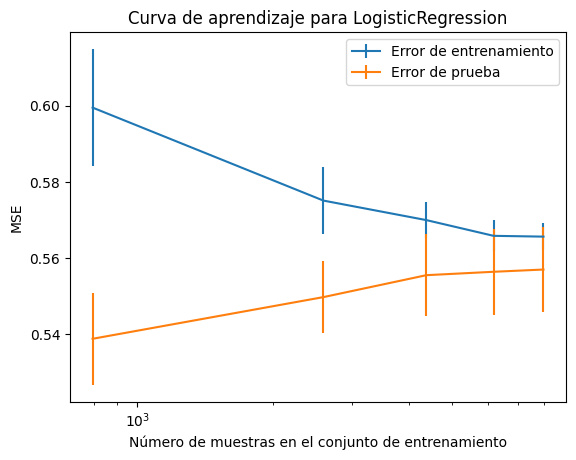

In [ ]:
for pipeline_name, pipeline_obj in pipelines.items():
    generate_learning_curves(pipeline_name, pipeline_obj, X, y, train_sizes)

### Curva validación

In [1]:
# Curvas de validación

def generate_validation_curves(name, pipeline, X, y, param_name, param_range):
    train_scores, test_scores = validation_curve(
        pipeline, X, y, param_name=param_name, param_range=param_range,
        cv=cvss, scoring="accuracy")

    # graficar la curva.
    plt.plot(param_range, train_scores.mean(
        axis=1), label="Error de entrenamiento")
    plt.plot(param_range, test_scores.mean(axis=1), label="Error de prueba")
    plt.legend()

    plt.xlabel("Valor del ({param_name})".format(
        param_name=param_name))
    plt.ylabel("Accuracy")
    plt.title("Curva de validación para {name}".format(name=name))

    plt.show()

In [2]:
pname = 'LogisticRegression'
Cs = [0,0.1, 1, 5, 10, 12]
generate_validation_curves(pname, pipelines[pname], X, y, 'classifier__C', Cs)

NameError: name 'pipelines' is not defined

In [3]:
pname = 'RandomForestClassifier'
n_estimators_ops = [1,2,3,4,5]
generate_validation_curves(pname, pipelines[pname], X, y, 'classifier__n_estimators', n_estimators_ops)

NameError: name 'pipelines' is not defined

In [ ]:
pname = 'GradientBoostingClassifier'
n_estimators_ops = [1,2,3,4,5,10]
generate_validation_curves(pname, pipelines[pname], X, y, 'classifier__n_estimators', n_estimators_ops)

In [ ]:
pname = 'SGDClassifier'
n_estimators_ops = [1,2,3,4,5,10]
generate_validation_curves(pname, pipelines[pname], X, y, 'classifier__n_estimators', n_estimators_ops)